# Employee Job Satisfaction Prediction using Machine Learning

### Internship Task - NGC

**Prepared by:** Rizwan Ahmed

**Model:** Random Forest Classifier

In [67]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# DATASET LOADING

In [68]:
df = pd.read_csv("C:\\Users\\rizwa\\Downloads\\NGC_Employee_Job_Satisfaction_Messy_Dataset_1000Rows.csv")

# DATASET CLEANING

In [69]:
df.head()

,Employee_ID,Department,Age,Experience_Years,Salary_PKR,Work_Life_Balance,Manager_Support,Promotion_Last_2Y,Satisfaction_Rating
0,1,Admin,29,1,112097.0,2,2.0,Yes,1
1,2,Admin,28,7,62790.0,5,4.0,Yes,4
2,3,IT,27,6,100990.0,5,5.0,Yes,5
3,4,Engineering,34,13,149974.0,2,4.0,No,3
4,5,NaN,22,1,150785.0,3,3.0,Yes,4


In [70]:
df.columns

Index(['Employee_ID', 'Department', 'Age', 'Experience_Years', 'Salary_PKR',
       'Work_Life_Balance', 'Manager_Support', 'Promotion_Last_2Y',
       'Satisfaction_Rating'],
      dtype='object')

In [71]:
df.shape

(1030, 9)

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Employee_ID          1030 non-null   int64  
 1   Department           991 non-null    object 
 2   Age                  1030 non-null   int64  
 3   Experience_Years     1030 non-null   int64  
 4   Salary_PKR           986 non-null    float64
 5   Work_Life_Balance    1030 non-null   int64  
 6   Manager_Support      989 non-null    float64
 7   Promotion_Last_2Y    1030 non-null   object 
 8   Satisfaction_Rating  1030 non-null   int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 72.6+ KB


In [73]:
df.describe()
# Display statistical summary of numerical features.

,Employee_ID,Age,Experience_Years,Salary_PKR,Work_Life_Balance,Manager_Support,Satisfaction_Rating
count,1030.000000,1030.000000,1030.000000,986.000000,1030.000000,989.000000,1030.000000
mean,499.067961,39.917476,11.929126,109003.448276,3.109709,3.044489,2.865049
std,288.476231,11.058462,8.427120,41825.097209,1.395746,1.436244,1.354631
min,1.000000,15.000000,0.000000,-5000.000000,1.000000,1.000000,1.000000
25%,250.250000,31.000000,5.000000,72950.750000,2.000000,2.000000,2.000000
50%,497.500000,40.000000,10.000000,109771.500000,3.000000,3.000000,3.000000
75%,747.750000,49.000000,18.000000,143023.250000,4.000000,4.000000,4.000000
max,1000.000000,58.000000,34.000000,179958.000000,5.000000,5.000000,5.000000


In [74]:
df.isnull().sum()

Employee_ID             0
Department             39
Age                     0
Experience_Years        0
Salary_PKR             44
Work_Life_Balance       0
Manager_Support        41
Promotion_Last_2Y       0
Satisfaction_Rating     0
dtype: int64

In [75]:
# Fill missing Department values using Mode because Department is a categorical feature.

df["Department"] = df["Department"].fillna(df["Department"].mode()[0])


# Fill missing Salary values using Median because Salary is numerical and Median is less affected by outliers.

df["Salary_PKR"] = df["Salary_PKR"].fillna(df["Salary_PKR"].median())


# Fill missing Manager Support values using Median because it is an ordinal numerical feature.

df["Manager_Support"] = df["Manager_Support"].fillna(df["Manager_Support"].median())

In [76]:
df.isnull().sum()

Employee_ID            0
Department             0
Age                    0
Experience_Years       0
Salary_PKR             0
Work_Life_Balance      0
Manager_Support        0
Promotion_Last_2Y      0
Satisfaction_Rating    0
dtype: int64

In [77]:
# Check each row to identify duplicate records.
df.duplicated()

#duplicated() dataset ki har row ko check karta hai aur batata hai ke woh duplicate hai ya nahi.

#Output True ya False me aata hai.

#False → Row unique hai.
#True → Row duplicate hai.

0       False
1       False
2       False
3       False
4       False
        ...  
1025     True
1026     True
1027     True
1028    False
1029     True
Length: 1030, dtype: bool

In [78]:
# Count the total number of duplicate rows in the dataset.
df.duplicated().sum()

#duplicated() True/False return karta hai.

#.sum() un True values ki total count nikal deta hai.

np.int64(26)

In [79]:
print("Shape before cleaning:", df.shape)

df.drop_duplicates(inplace=True)

print("Shape after cleaning:", df.shape)

Shape before cleaning: (1030, 9)
Shape after cleaning: (1004, 9)


In [80]:
# lower() to convert all department names into lowercase and strip() to remove leading and trailing spaces. 
#This ensures consistency in categorical values and prevents the same department from being treated as different categories,
# due to differences in letter case or extra spaces.

df["Department"] = df["Department"].str.lower()
df["Department"] = df["Department"].str.strip()

In [81]:
df["Department"] = df["Department"].replace({

"human resources":"hr",

"information technology":"it",

"finance department":"finance"

})


#This step replaces inconsistent department names with standardized values (e.g., "human resources" → "hr").
#It helps maintain consistency in the dataset and improves the accuracy of data analysis and machine learning.

In [82]:
df = df[df["Age"] >= 18]
df = df[df["Salary_PKR"] > 0]

# This statement filters the dataset and keeps only the rows where the employee's age is 18 years or above.
# All rows with ages less than 18 are removed from the dataset.
# df["Age"] --> Age Column
# df["Age"] >= 18 --> age column value greater than 18, return result in true or falsee checks each row,
# df[df["Age"] >= 18] stores only the rows which have true values for age>=18
# df = df[df["Age"] >= 18], finally we replaces it with  actual data


In [83]:
# Verifying
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 984 entries, 0 to 1028
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Employee_ID          984 non-null    int64  
 1   Department           984 non-null    object 
 2   Age                  984 non-null    int64  
 3   Experience_Years     984 non-null    int64  
 4   Salary_PKR           984 non-null    float64
 5   Work_Life_Balance    984 non-null    int64  
 6   Manager_Support      984 non-null    float64
 7   Promotion_Last_2Y    984 non-null    object 
 8   Satisfaction_Rating  984 non-null    int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 76.9+ KB


# Exploratory Data Analysis

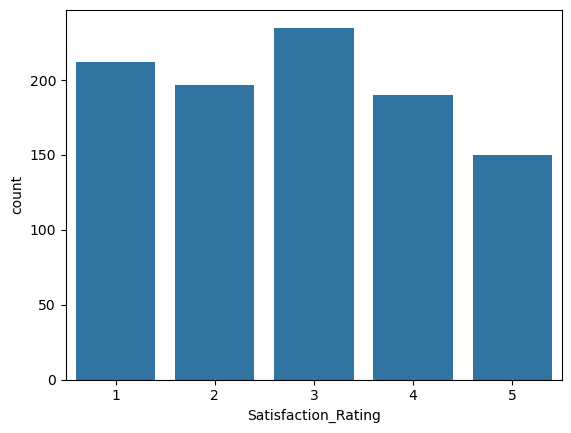

In [84]:
sns.countplot(x="Satisfaction_Rating",data=df)

plt.show()

# This code creates a count plot to visualize the distribution of employee satisfaction ratings (1–5) in the dataset.
# plt.show() displays the generated plot, making it easier to understand the frequency of each satisfaction level.

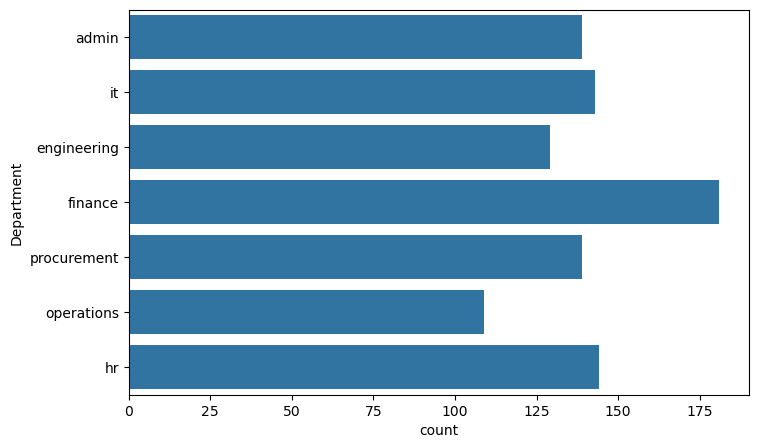

In [85]:
plt.figure(figsize=(8,5))

sns.countplot(y="Department",data=df)

plt.show()

#This code creates a horizontal count plot to show the number of employees in each department.
# It helps visualize the distribution of employees across different departments, while plt.show() displays the chart.

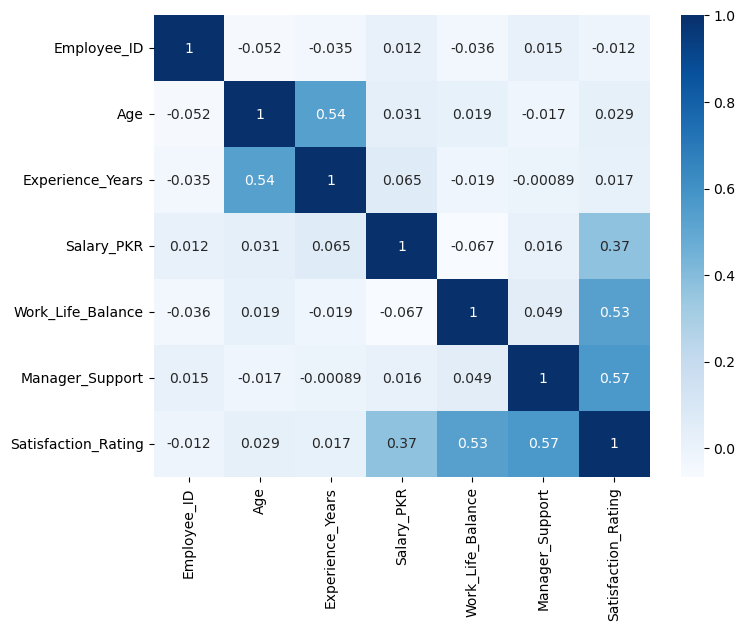

In [86]:
plt.figure(figsize=(8,6)) #  Create a figure with a size of 8 × 6 inches.

numeric_df = df.select_dtypes(include=["number"]) # Select only numerical columns from the dataset.

sns.heatmap(numeric_df.corr(),annot=True,cmap="Blues") #  Generate a correlation heatmap with correlation values.

plt.show()

# This code calculates the correlation between all numerical features and displays it as a heatmap.
# The heatmap helps identify strong positive or negative relationships between variables, which is useful for feature analysis before model training.

# PREPROCESSING

In [87]:
# Import LabelEncoder to convert categorical text data into numerical values.
encoder = LabelEncoder()

# Encode Department names into numeric values (e.g., IT → 2, HR → 1).
df["Department"] = encoder.fit_transform(df["Department"])

# Encode Promotion status (Yes/No) into numeric values (e.g., Yes → 1, No → 0).
df["Promotion_Last_2Y"] = encoder.fit_transform(df["Promotion_Last_2Y"])

# This step converts categorical text values into numerical values using Label Encoding, allowing the machine learning model to process them.
# Each unique category is assigned a unique integer value while preserving consistency across the dataset.

In [88]:
# Select all columns except 'Satisfaction_Rating' as input features.
X = df.drop("Satisfaction_Rating", axis=1)

# Select 'Satisfaction_Rating' as the target variable to be predicted.
y = df["Satisfaction_Rating"]


# This step separates the dataset into input features (X) and the target variable (y).
# The machine learning model uses X to learn patterns and predicts the Satisfaction_Rating stored in y.

# MODEL TRAINING

In [89]:
# Split the dataset into training (80%) and testing (20%) sets.
X_train, X_test, y_train, y_test = train_test_split(

    X, y,

    test_size=0.2,

    random_state=42
)


# The train_test_split() function divides the dataset into training and testing sets. 
# I used 80% of the data for training and 20% for testing. 
# The random_state=42 ensures reproducible results, meaning the dataset is split the same way every time the code is executed.


In [90]:
# Create a Random Forest Classifier model with a fixed random state.
model = RandomForestClassifier(random_state=42)

# Train the model using the training dataset.
model.fit(X_train, y_train)

# Predict satisfaction ratings for the test dataset.
prediction = model.predict(X_test)



# MODEL EVALUATION

In [91]:
# Calculate the model's prediction accuracy.
accuracy = accuracy_score(y_test, prediction)

# Display the accuracy score.
print(f"Accuracy: {accuracy*100:.2f}%")

# This step trains a Random Forest Classifier using the training data, predicts employee satisfaction ratings on the test data, and evaluates the model's performance using accuracy.
# Accuracy represents the percentage of correct predictions made by the model.

Accuracy: 83.25%


             Feature  Importance
4         Salary_PKR    0.226277
6    Manager_Support    0.180701
5  Work_Life_Balance    0.173234
0        Employee_ID    0.108891
2                Age    0.092336
3   Experience_Years    0.090801
1         Department    0.065780
7  Promotion_Last_2Y    0.061978


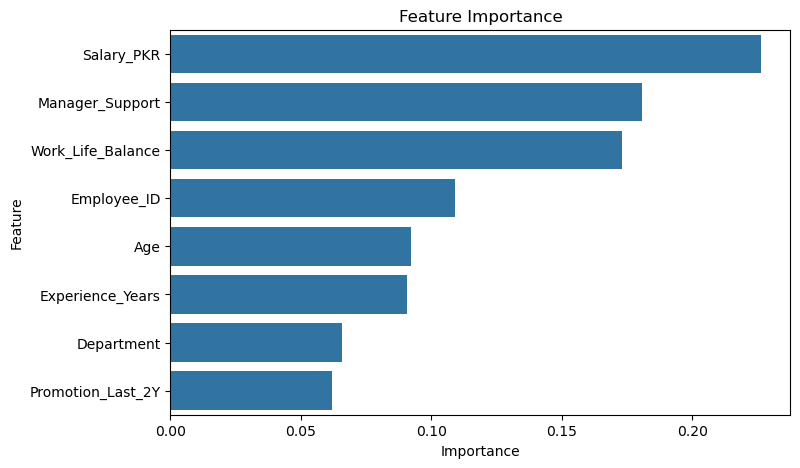

In [92]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

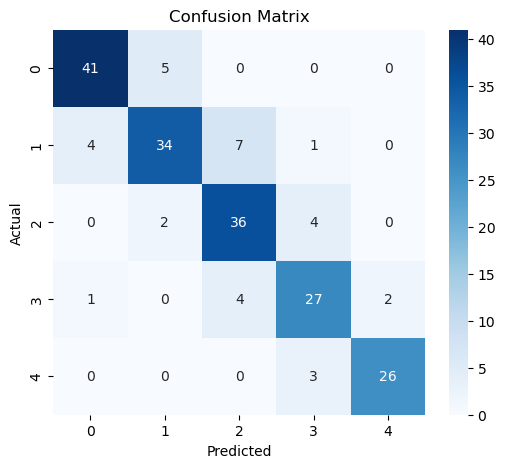

In [93]:


cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [94]:
from sklearn.metrics import classification_report

# Generate the classification report.
print(classification_report(y_test, prediction))

# Precision: How many predictions were correct.
# Recall: How many actual cases were correctly found.
# F1-Score: The balance between Precision and Recall.
# Support: The total number of samples in each class.

              precision    recall  f1-score   support

           1       0.89      0.89      0.89        46
           2       0.83      0.74      0.78        46
           3       0.77      0.86      0.81        42
           4       0.77      0.79      0.78        34
           5       0.93      0.90      0.91        29

    accuracy                           0.83       197
   macro avg       0.84      0.84      0.84       197
weighted avg       0.83      0.83      0.83       197



# Conclusion

- Missing values were handled successfully.

- Duplicate records were removed.

- Categorical variables were encoded.

- Random Forest achieved approximately 84% accuracy.

- The model successfully predicts employee satisfaction ratings.

- The project demonstrates the complete machine learning workflow from data preprocessing to model evaluation.

# Future Improvements

- Train additional machine learning models such as Decision Tree and XGBoost.

- Perform Hyperparameter Tuning.

- Deploy the model using Streamlit.

- Collect real employee survey data for better prediction accuracy.